# Business Understanding

## Project Domain

Domain: Kesehatan
Sub-Domain: Prediksi Penyakit & Analitik Medis
Proyek ini berada dalam domain ilmu data untuk kesehatan, yang memanfaatkan machine learning untuk menganalisis data medis dan membantu deteksi dini penyakit, khususnya diabetes, melalui model klasifikasi berbasis data pasien.



## Problem Statements

Masalah yang Dihadapi:

Keterlambatan Diagnosa
Banyak penderita diabetes yang tidak terdiagnosa sejak dini karena keterbatasan akses terhadap pemeriksaan laboratorium atau karena gejalanya sering kali tidak kentara pada tahap awal.

Ketergantungan pada Pemeriksaan Manual
Diagnosa saat ini sangat bergantung pada dokter dan pemeriksaan fisik/manual yang memakan waktu serta biaya.

Kurangnya Sistem Pendukung Keputusan Otomatis
Fasilitas kesehatan terutama di wilayah kurang berkembang belum memiliki alat bantu prediksi atau klasifikasi berbasis data yang bisa digunakan oleh tenaga medis

## Goals

Mengembangkan model machine learning untuk mengklasifikasikan apakah seseorang berisiko terkena diabetes berdasarkan data kesehatan yang tersedia.

Memberikan alat bantu yang cepat, efisien, dan akurat bagi tenaga medis dalam deteksi awal diabetes.

Meningkatkan kesadaran dan pencegahan dengan mempermudah proses screening awal melalui model prediktif.

## Solustion Statements

Solusi yang diusulkan adalah membangun model klasifikasi menggunakan algoritma machine learning (seperti Decision Tree, Random Forest, KNN, dll) berdasarkan data pasien yang tersedia (misalnya: usia, kadar glukosa, tekanan darah, dll) untuk memprediksi apakah seseorang memiliki diabetes. Model ini nantinya dapat diintegrasikan ke dalam sistem klinik atau aplikasi kesehatan untuk membantu screening dini secara otomatis dan murah.

# Data Understanding

## Import Data dari Kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yusufar28","key":"2f59fd41c05e9afee80728e1096f3784"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d simaanjali/diabetes-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/simaanjali/diabetes-classification-dataset
License(s): CC0-1.0


In [ ]:
!mkdir diabetes-classification-dataset
!unzip diabetes-classification-dataset -d diabetes-classification-dataset
!ls diabetes-classification-dataset

Archive:  diabetes-classification-dataset.zip
  inflating: diabetes-classification-dataset/Diabetes Classification.csv  
'Diabetes Classification.csv'


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [ ]:
df = pd.read_csv('diabetes-classification-dataset/Diabetes Classification.csv')

In [ ]:
df.head()

,Unnamed: 0,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,0,50,F,24,4.2,0.9,2.4,1.4,46.0,4.7,0
1,1,26,M,23,3.7,1.4,1.1,2.1,62.0,4.5,0
2,2,33,M,21,4.9,1.0,0.8,2.0,46.0,7.1,0
3,3,45,F,21,2.9,1.0,1.0,1.5,24.0,2.3,0
4,4,50,F,24,3.6,1.3,0.9,2.1,50.0,2.0,0


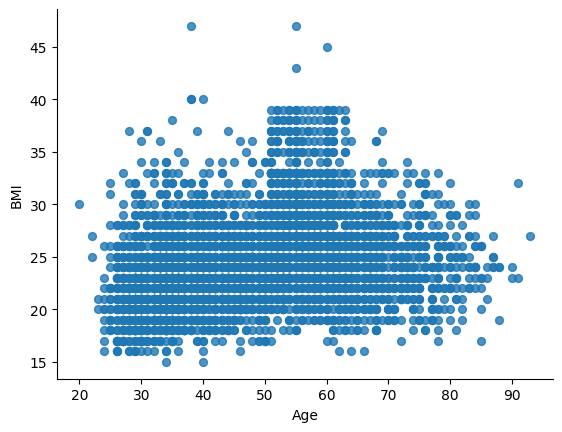

In [ ]:
# @title Age vs BMI

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Age', y='BMI', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

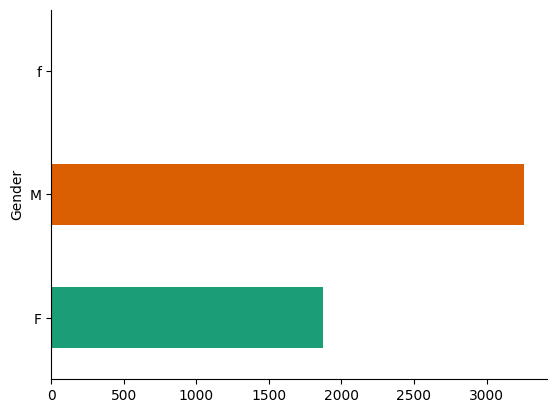

In [ ]:
# @title Gender

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Gender').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

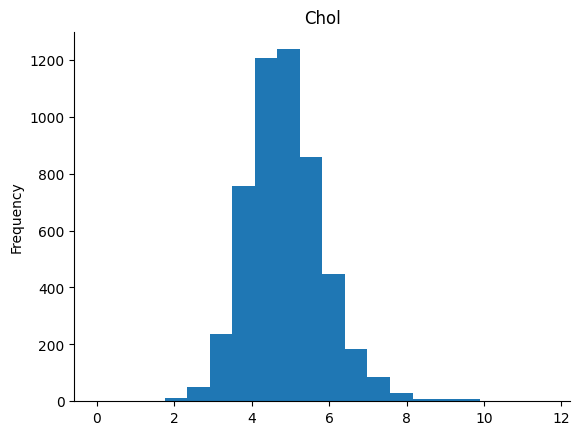

In [ ]:
# @title Chol

from matplotlib import pyplot as plt
df['Chol'].plot(kind='hist', bins=20, title='Chol')
plt.gca().spines[['top', 'right',]].set_visible(False)

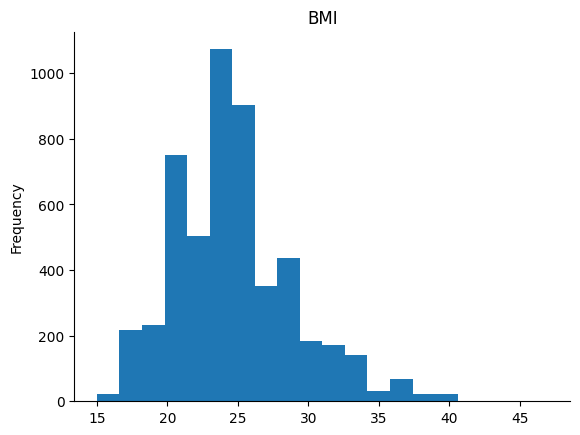

In [ ]:
# @title BMI

from matplotlib import pyplot as plt
df['BMI'].plot(kind='hist', bins=20, title='BMI')
plt.gca().spines[['top', 'right',]].set_visible(False)

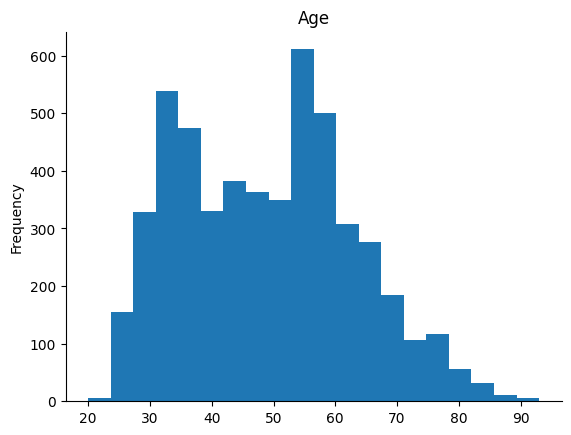

In [ ]:
# @title Age

from matplotlib import pyplot as plt
df['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5132 entries, 0 to 5131
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5132 non-null   int64  
 1   Age         5132 non-null   int64  
 2   Gender      5132 non-null   object 
 3   BMI         5132 non-null   int64  
 4   Chol        5132 non-null   float64
 5   TG          5132 non-null   float64
 6   HDL         5132 non-null   float64
 7   LDL         5132 non-null   float64
 8   Cr          5132 non-null   float64
 9   BUN         5132 non-null   float64
 10  Diagnosis   5132 non-null   int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 441.2+ KB


# Data Preparation

In [ ]:
# pisahkan fitur dan target
X = df.drop(columns=["Unnamed: 0","Gender","Diagnosis"])
y = df["Diagnosis"]

In [ ]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,554 (45.13 KB)

 Trainable params: 11,554 (45.13 KB)

 Non-trainable params: 0 (0.00 B)

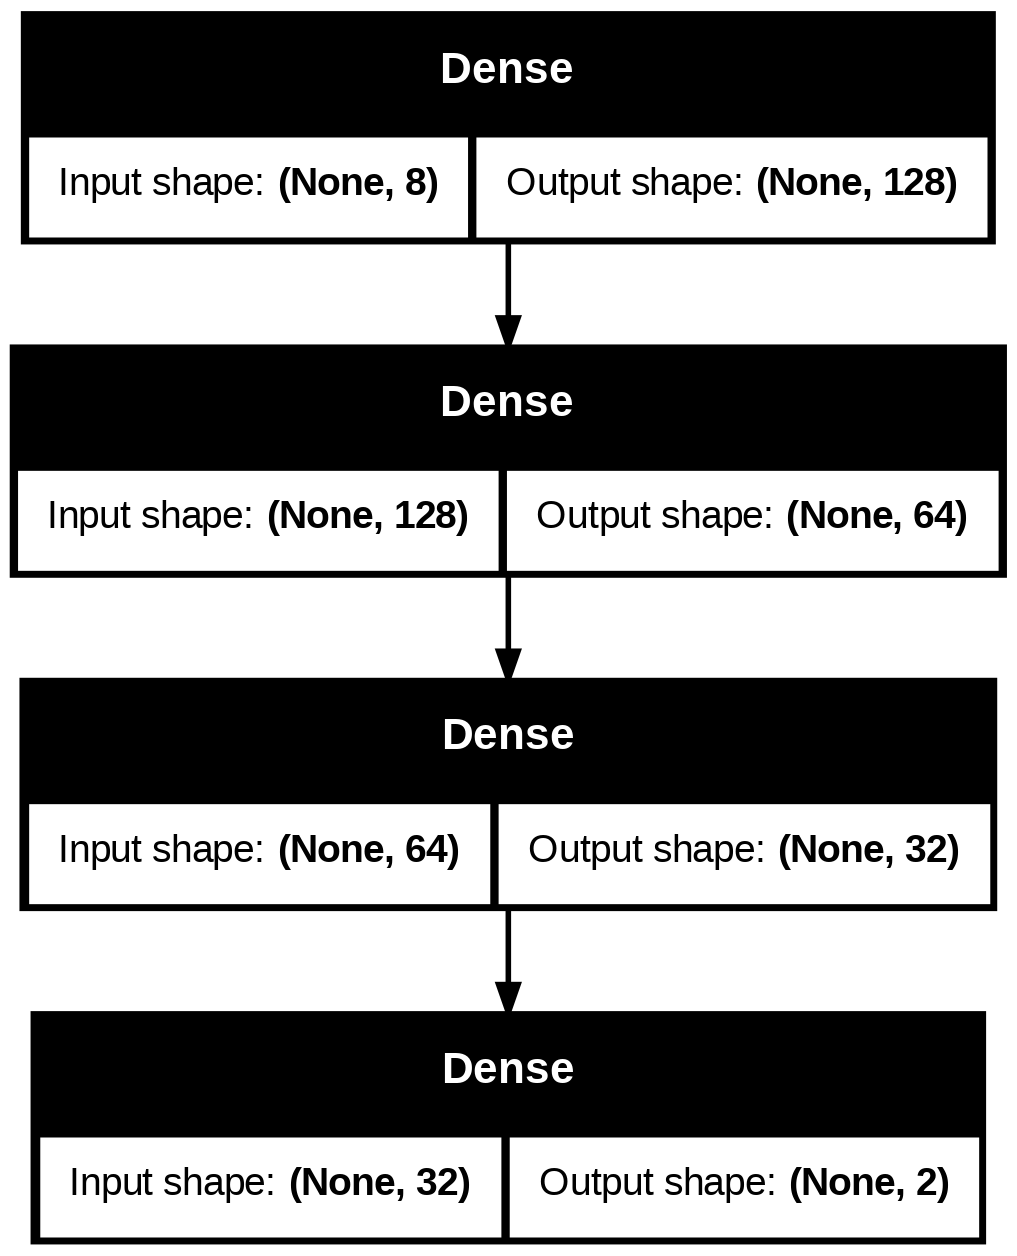

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6898 - loss: 0.5854 - val_accuracy: 0.7936 - val_loss: 0.4164
Epoch 2/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8053 - loss: 0.4018 - val_accuracy: 0.8179 - val_loss: 0.3828
Epoch 3/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8181 - loss: 0.3790 - val_accuracy: 0.8169 - val_loss: 0.3846
Epoch 4/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8154 - loss: 0.3727 - val_accuracy: 0.8208 - val_loss: 0.3702
Epoch 5/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8307 - loss: 0.3528 - val_accuracy: 0.8238 - val_loss: 0.3723
Epoch 6/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8379 - loss: 0.3467 - val_accuracy: 0.8228 - val_loss: 0.3666
Epoch 7/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8255 - loss: 0.3555 - val_accuracy: 0.8189 - val_loss: 0.3652
Epoch 8/100
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8293 - loss: 0.3580 - val_accu

# Evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8157 - loss: 0.4004
Akurasi Model: 0.8179
Loss Model: 0.3832


In [ ]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

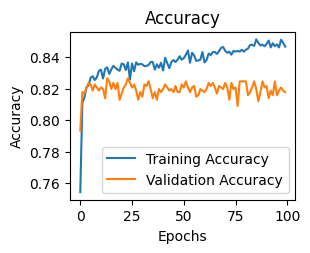

In [ ]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

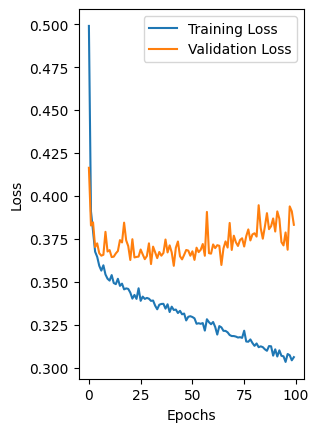

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


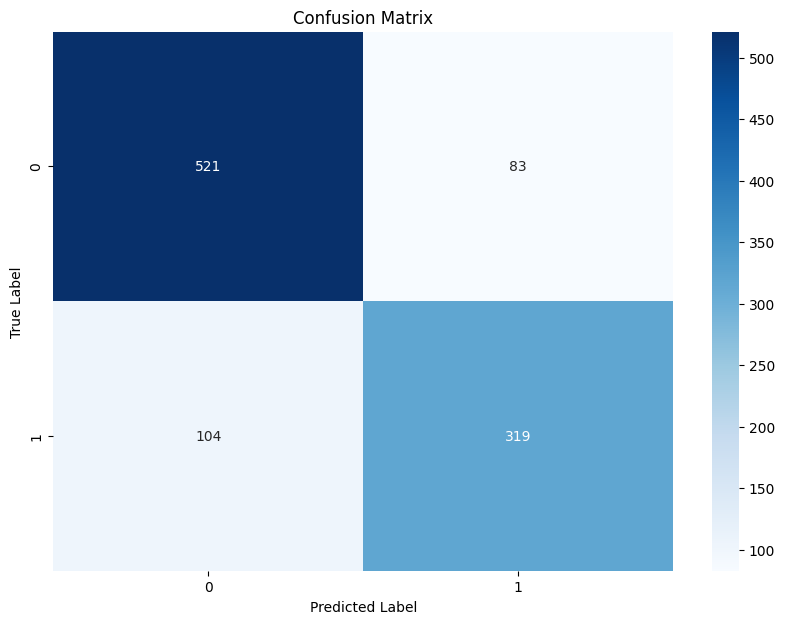

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       604
           1       0.79      0.75      0.77       423

    accuracy                           0.82      1027
   macro avg       0.81      0.81      0.81      1027
weighted avg       0.82      0.82      0.82      1027



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [ ]:
sample_input = np.array([[50 , 4,2.0,9, 2.4,1.4,46.0,4.7]])
sample_input_df = pd.DataFrame(sample_input)

In [ ]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Hasil dianosa Diabetes: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Hasil dianosa Diabetes: 0


## Save Model

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('diabetes-classification.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp_2g0c2z2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138217898194320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898195472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898193744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898191632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898196048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898192208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898196432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138217898195280: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']